# Baby Cry Sense Dataset — Feature Engineering

## Purpose

This notebook converts the preprocessed audio files into Log-Mel Spectrograms
and saves them as NumPy arrays for model training. It is the bridge between the
raw waveform domain (handled in `02_DataPreprocessing.ipynb`) and the model
training domain (handled in `04_baseline_ml.ipynb`).

## What This Notebook Does

1. Load the clean manifest and verify class distribution
2. Justify all spectrogram hyperparameters with mathematics
3. Generate Log-Mel Spectrograms for all 1334 preprocessed audio files
4. Visualise spectrograms per class, confused pairs, and waveform comparisons
5. Verify output array shape: `(1334, 128, 302)`
6. Save `X.npy`, `y.npy`, and `label_encoder.json`

## Dependencies

- `02_DataPreprocessing.ipynb` must have been run first.
- Reads from: `data/processed/clean_manifest.csv`
- Reads audio from: `data/processed/audio_clean/<category>/<file>.wav`
- Saves to: `data/processed/X.npy`, `data/processed/y.npy`,
  `data/processed/label_encoder.json`


## Section 1 — Imports and Setup

In [29]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("All libraries imported successfully.")
print(f"  librosa version : {librosa.__version__}")
print(f"  numpy  version  : {np.__version__}")


All libraries imported successfully.
  librosa version : 0.11.0
  numpy  version  : 2.0.2


## Section 1.1 — Path Configuration

Adapt `BASE_DIR` to your environment. On Kaggle the preprocessed dataset is
mounted under `/kaggle/input/baby-cry-preprocessed-dataset/`.
Locally it lives under `data/processed/`.


In [30]:
# ── Kaggle ──────────────────────────────────────────────────────────────────
# Uncomment the block below when running on Kaggle.
import os, sys
KAGGLE_INPUT = "/kaggle/input/datasets/noxpie/baby-cry-preprocessed-dataset"
DATASET_ROOT = os.path.join(KAGGLE_INPUT, "BabyCryDataset_processed")

MANIFEST_PATH  = os.path.join(DATASET_ROOT, "clean_manifest.csv")
AUDIO_BASE_DIR = os.path.join(DATASET_ROOT, "audio_clean")

OUTPUT_DIR     = "/kaggle/working"
REPORTS_DIR    = os.path.join(OUTPUT_DIR, "reports")

# ── Local ────────────────────────────────────────────────────────────────────
# MANIFEST_PATH  = "data/processed/clean_manifest.csv"
# AUDIO_BASE_DIR = "data/processed/audio_clean"
# OUTPUT_DIR     = "data/processed"
# REPORTS_DIR    = "reports"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

print(f"Manifest path  : {MANIFEST_PATH}")
print(f"Audio base dir : {AUDIO_BASE_DIR}")
print(f"Output dir     : {OUTPUT_DIR}")
print(f"Reports dir    : {REPORTS_DIR}")


Manifest path  : /kaggle/input/datasets/noxpie/baby-cry-preprocessed-dataset/BabyCryDataset_processed/clean_manifest.csv
Audio base dir : /kaggle/input/datasets/noxpie/baby-cry-preprocessed-dataset/BabyCryDataset_processed/audio_clean
Output dir     : /kaggle/working
Reports dir    : /kaggle/working/reports


## Section 2 — Load Manifest and Verify Class Distribution

The manifest was produced by `02_DataPreprocessing.ipynb` and contains one row
per audio file with the columns: `file_path`, `file_name`, `category`,
`sample_rate`, `duration_sec`, `num_samples`, `is_augmented`.

We verify the class distribution and the augmented-vs-original split before
generating any spectrograms.


In [31]:
df_manifest = pd.read_csv(MANIFEST_PATH)

print("MANIFEST LOADED")
print("=" * 60)
print(f"  Total files    : {len(df_manifest)}")
print(f"  Columns        : {list(df_manifest.columns)}")
print(f"  Augmented      : {df_manifest['is_augmented'].sum()}")
print(f"  Original       : {(~df_manifest['is_augmented']).sum()}")
print()
print("CLASS DISTRIBUTION")
print("-" * 60)
print(f"  {'Category':>15s} | {'Total':>5s} | {'Original':>8s} | {'Augmented':>9s} | {'Aug %':>6s}")
print(f"  {'-' * 55}")

for cat in sorted(df_manifest['category'].unique()):
    cat_df   = df_manifest[df_manifest['category'] == cat]
    total    = len(cat_df)
    original = int((~cat_df['is_augmented']).sum())
    aug      = int(cat_df['is_augmented'].sum())
    aug_pct  = aug / total * 100
    print(f"  {cat:>15s} | {total:>5d} | {original:>8d} | {aug:>9d} | {aug_pct:>5.1f}%")

print(f"  {'-' * 55}")
print(f"  {'TOTAL':>15s} | {len(df_manifest):>5d} | {(~df_manifest['is_augmented']).sum():>8d} | {df_manifest['is_augmented'].sum():>9d} |")


MANIFEST LOADED
  Total files    : 1334
  Columns        : ['file_path', 'file_name', 'category', 'sample_rate', 'duration_sec', 'num_samples', 'is_augmented']
  Augmented      : 209
  Original       : 1125

CLASS DISTRIBUTION
------------------------------------------------------------
         Category | Total | Original | Augmented |  Aug %
  -------------------------------------------------------
       belly pain |   133 |      133 |         0 |   0.0%
          burping |   130 |      124 |         6 |   4.6%
         cold_hot |   130 |      130 |         0 |   0.0%
       discomfort |   142 |      142 |         0 |   0.0%
           hungry |   397 |      397 |         0 |   0.0%
           lonely |   130 |       24 |       106 |  81.5%
           scared |   130 |       33 |        97 |  74.6%
            tired |   142 |      142 |         0 |   0.0%
  -------------------------------------------------------
            TOTAL |  1334 |     1125 |       209 |


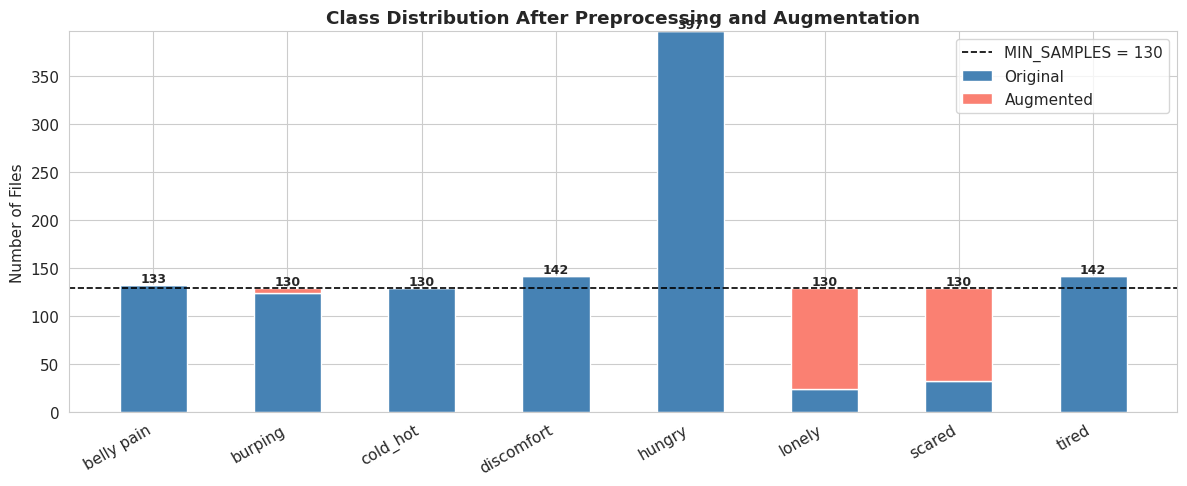

Saved: class_distribution_post_preprocessing.png


In [32]:
fig, ax = plt.subplots(figsize=(12, 5))

cats        = sorted(df_manifest['category'].unique())
orig_counts = [int((~df_manifest[df_manifest['category'] == c]['is_augmented']).sum()) for c in cats]
aug_counts  = [int(df_manifest[df_manifest['category'] == c]['is_augmented'].sum()) for c in cats]

x = np.arange(len(cats))
w = 0.5

bars_orig = ax.bar(x, orig_counts, w, label='Original', color='steelblue')
bars_aug  = ax.bar(x, aug_counts,  w, bottom=orig_counts, label='Augmented', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=30, ha='right')
ax.set_ylabel('Number of Files')
ax.set_title('Class Distribution After Preprocessing and Augmentation', fontweight='bold')
ax.axhline(y=130, color='black', linestyle='--', linewidth=1.2, label='MIN_SAMPLES = 130')
ax.legend()

for bar, val in zip(bars_orig, [o + a for o, a in zip(orig_counts, aug_counts)]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 3,
            str(val), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'class_distribution_post_preprocessing.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution_post_preprocessing.png")


## Section 3 — Spectrogram Parameters and Mathematical Justification

### Why Log-Mel Spectrograms?

Raw waveforms encode audio as amplitude-over-time. Two very different cry types
can produce nearly identical amplitude envelopes. The Log-Mel Spectrogram
decomposes each frame of audio into its frequency components, revealing harmonic
structure, formant patterns, and spectral envelopes that are class-discriminative.
By treating the resulting 2-D image as a CNN input we leverage the inductive bias
of convolutional filters to detect local spectro-temporal patterns — something a
classifier operating on raw samples cannot do without learning to perform the
frequency decomposition from scratch.

---

### Step 1 — Short-Time Fourier Transform (STFT)

The signal $x[n]$ is divided into overlapping frames of length $N$ using a window
$w[n]$. For each frame at time $t$, the DFT is computed:

$$X[k, t] = \sum_{n=0}^{N-1} x[n + t \cdot H] \; w[n] \; e^{-j 2\pi k n / N}$$

where $k$ is the frequency bin index, $H$ is the hop length, and $|X[k,t]|^2$
gives the power spectrogram.

**Parameter choices:**

| Parameter | Value | Justification |
|-----------|-------|---------------|
| `n_fft` | 2048 | Window of 93 ms at 22050 Hz. Long enough to resolve frequencies down to ~11 Hz; short enough to track temporal changes in cry structure. |
| `hop_length` | 512 | Stride of 23 ms = 75% frame overlap. Standard for audio classification; balances temporal resolution and computation. |

---

### Step 2 — Mel Filterbank

The linear frequency axis (0–11025 Hz) is warped to the Mel scale, which
approximates human auditory resolution. Lower frequencies are spaced more
finely because the cochlea is more sensitive to pitch differences there:

$$m = 2595 \times \log_{10}\!\left(1 + \frac{f}{700}\right)$$

`n_mels = 128` triangular filters are applied to the power spectrogram.
128 matches the resolution of human critical-band analysis and is the
de-facto standard in audio CNN literature.

`fmax = 8000 Hz`: infant cry fundamentals lie in 250–600 Hz with harmonics
up to ~4 kHz. Harmonics above 8 kHz carry negligible classification information
and are excluded to reduce noise from upsampled 8-kHz files.

---

### Step 3 — Logarithmic Compression

The Mel power spectrogram is converted to decibels:

$$S_{dB}[m, t] = 10 \times \log_{10}\!\left(\frac{S[m,t]}{S_{\max}}\right)$$

Log compression is essential because:
1. Human loudness perception is logarithmic (Weber–Fechner law).
2. Acoustic energy spans several orders of magnitude; dB normalises this range.
3. Quiet formants that distinguish cry types become visible after compression.

---

### Output Shape Derivation

With `center=True` (librosa default), the signal is padded by $N/2 = 1024$
samples on each side before framing:

$$T = \left\lfloor \frac{L + N - H}{H} \right\rfloor = \left\lfloor \frac{154350 + 2048 - 512}{512} \right\rfloor = 302 \text{ frames}$$

Final spectrogram shape: **(128 mel bins × 302 time frames)** per file.


In [33]:
# ── Spectrogram hyperparameters ──────────────────────────────────────────────
TARGET_SR       = 22050
TARGET_DURATION = 7.0
TARGET_SAMPLES  = int(TARGET_SR * TARGET_DURATION)   # 154350

N_MELS     = 128
N_FFT      = 2048
HOP_LENGTH = 512
FMAX       = 8000

# Verify output shape analytically
import math
padded_len  = TARGET_SAMPLES + 2 * (N_FFT // 2)          # centre-padding
T_FRAMES    = math.floor((padded_len - N_FFT) / HOP_LENGTH) + 1

print("SPECTROGRAM PARAMETER SUMMARY")
print("=" * 50)
print(f"  TARGET_SR       = {TARGET_SR} Hz")
print(f"  TARGET_DURATION = {TARGET_DURATION} s")
print(f"  TARGET_SAMPLES  = {TARGET_SAMPLES}")
print(f"  N_MELS          = {N_MELS}  (mel frequency bins)")
print(f"  N_FFT           = {N_FFT}  (window = {N_FFT/TARGET_SR*1000:.0f} ms)")
print(f"  HOP_LENGTH      = {HOP_LENGTH}  (stride = {HOP_LENGTH/TARGET_SR*1000:.0f} ms, {(1 - HOP_LENGTH/N_FFT)*100:.0f}% overlap)")
print(f"  FMAX            = {FMAX} Hz")
print()
print(f"  Expected output shape per file : ({N_MELS}, {T_FRAMES})")
print(f"  Expected X array shape         : ({len(df_manifest)}, {N_MELS}, {T_FRAMES})")


SPECTROGRAM PARAMETER SUMMARY
  TARGET_SR       = 22050 Hz
  TARGET_DURATION = 7.0 s
  TARGET_SAMPLES  = 154350
  N_MELS          = 128  (mel frequency bins)
  N_FFT           = 2048  (window = 93 ms)
  HOP_LENGTH      = 512  (stride = 23 ms, 75% overlap)
  FMAX            = 8000 Hz

  Expected output shape per file : (128, 302)
  Expected X array shape         : (1334, 128, 302)


### Why This Representation Simplifies the Learning Task

The Log-Mel Spectrogram converts a 1D waveform classification
problem into a 2D image classification problem. This matters
because:

1. EDA showed nearest-neighbor purity on 41-dimensional MFCC
   feature vectors is 0.350 — barely above random baseline.
   The spectrogram preserves ALL temporal dynamics discarded
   by MFCC aggregation, giving the CNN access to the full
   time-frequency structure.

2. The (128, 302) spectrogram explicitly encodes harmonic
   patterns as horizontal bands — directly visible to
   convolutional filters through weight sharing. The same
   harmonic pattern at t=1.2s and t=3.5s is detected by
   the same filter weights.

3. Abbaskhah et al. (2023) demonstrated that CNN on MFCC
   features outperforms SVM — our system goes further by
   giving the CNN the full spectrogram rather than MFCC
   statistics, providing even richer spatial structure.

## Section 4 — Spectrogram Generation

Generate one Log-Mel Spectrogram per file. The pipeline per file:

1. Load the pre-normalised `.wav` at `TARGET_SR` (already at 22050 Hz — no resampling cost)
2. Assert exactly `TARGET_SAMPLES` samples (sanity check)
3. Compute power spectrogram via STFT
4. Apply Mel filterbank
5. Convert to dB scale with `ref=np.max` (peak normalisation in log domain)

The Kaggle input path is read-only, so `file_path` values in the manifest need
to be remapped to the mounted input location when running on Kaggle.


In [34]:
def resolve_audio_path(manifest_row, audio_base_dir):
    """
    Reconstruct the audio file path from category + file_name.

    The manifest was created locally (paths contain the machine's absolute path).
    On Kaggle, we rebuild the path from AUDIO_BASE_DIR + category + file_name
    so the notebook works regardless of where the manifest was generated.

    Parameters
    ----------
    manifest_row : pd.Series
        A single row from df_manifest.
    audio_base_dir : str
        Root directory that contains one sub-folder per category.

    Returns
    -------
    str
        Resolved path to the .wav file.
    """
    return os.path.join(audio_base_dir, manifest_row['category'], manifest_row['file_name'])


# Quick sanity check: verify 5 random paths resolve correctly
sample_rows = df_manifest.sample(5, random_state=42)
print("PATH RESOLUTION CHECK (5 random files)")
print("=" * 60)
all_ok = True
for _, row in sample_rows.iterrows():
    resolved = resolve_audio_path(row, AUDIO_BASE_DIR)
    exists   = os.path.exists(resolved)
    status   = "OK" if exists else "MISSING"
    if not exists:
        all_ok = False
    print(f"  [{status}] {row['category']}/{row['file_name']}")

if all_ok:
    print("\nAll sample paths resolved successfully.")
else:
    print("\nWARNING: Some paths are missing. Check AUDIO_BASE_DIR.")


PATH RESOLUTION CHECK (5 random files)
  [OK] scared/generated2_d6cda191-4962-4308-9a36-46d5648a95ed-1431700367302-1.7-m-04-sc.wav
  [OK] cold_hot/62c.wav
  [OK] scared/aug_scared_0015_add_noise.wav
  [OK] cold_hot/79c.wav
  [OK] burping/generated3_5afc6a14-a9d8-45f8-b31d-c79dd87cc8c6-1430757039803-1.7-m-48-bu.wav

All sample paths resolved successfully.


In [35]:
def generate_logmel_spectrogram(audio, sr=TARGET_SR, n_mels=N_MELS,
                                n_fft=N_FFT, hop_length=HOP_LENGTH,
                                fmax=FMAX):
    """
    Convert a pre-loaded audio waveform to a Log-Mel Spectrogram.

    Parameters
    ----------
    audio : np.ndarray, shape (TARGET_SAMPLES,)
        Peak-normalised mono waveform at TARGET_SR Hz.
    sr : int
        Sample rate (must equal TARGET_SR).
    n_mels : int
        Number of Mel filterbank channels.
    n_fft : int
        FFT window size in samples.
    hop_length : int
        STFT hop size in samples.
    fmax : float
        Highest frequency (Hz) included in the Mel filterbank.

    Returns
    -------
    np.ndarray, shape (n_mels, T_frames)
        Log-Mel spectrogram in dB, referenced to the maximum energy
        in the clip (range approximately −80 dB to 0 dB).
    """
    mel_spec    = librosa.feature.melspectrogram(
        y=audio, sr=sr,
        n_mels=n_mels, n_fft=n_fft, hop_length=hop_length,
        fmax=fmax
    )
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    return log_mel_spec


# ── Smoke test ───────────────────────────────────────────────────────────────
_test_row  = df_manifest.iloc[0]
_test_path = resolve_audio_path(_test_row, AUDIO_BASE_DIR)
_test_y, _ = librosa.load(_test_path, sr=TARGET_SR)

_test_spec  = generate_logmel_spectrogram(_test_y)

print(f"Smoke test: {_test_row['category']}/{_test_row['file_name']}")
print(f"  Input shape  : {_test_y.shape}")
print(f"  Output shape : {_test_spec.shape}")
print(f"  dB range     : [{_test_spec.min():.1f}, {_test_spec.max():.1f}]")
assert _test_spec.shape == (N_MELS, T_FRAMES), \
    f"Shape mismatch: expected ({N_MELS}, {T_FRAMES}), got {_test_spec.shape}"
print("  Shape assertion PASSED")


Smoke test: belly pain/379c.wav
  Input shape  : (154350,)
  Output shape : (128, 302)
  dB range     : [-80.0, 0.0]
  Shape assertion PASSED


In [36]:
# ── Label encoding ───────────────────────────────────────────────────────────
CLASSES       = sorted(df_manifest['category'].unique())
LABEL_ENCODER = {cls: idx for idx, cls in enumerate(CLASSES)}
LABEL_DECODER = {idx: cls for cls, idx in LABEL_ENCODER.items()}

print("LABEL ENCODING")
print("=" * 40)
for cls, idx in LABEL_ENCODER.items():
    print(f"  {idx}  →  {cls}")

# ── Allocate output arrays ────────────────────────────────────────────────────
N_FILES = len(df_manifest)
X = np.zeros((N_FILES, N_MELS, T_FRAMES), dtype=np.float32)
y = np.zeros(N_FILES, dtype=np.int32)

print(f"\nAllocated X: {X.shape}  ({X.nbytes / 1e6:.1f} MB)")
print(f"Allocated y: {y.shape}")


LABEL ENCODING
  0  →  belly pain
  1  →  burping
  2  →  cold_hot
  3  →  discomfort
  4  →  hungry
  5  →  lonely
  6  →  scared
  7  →  tired

Allocated X: (1334, 128, 302)  (206.3 MB)
Allocated y: (1334,)


In [37]:
failed_files = []

for i, (_, row) in enumerate(tqdm(df_manifest.iterrows(),
                                   total=N_FILES,
                                   desc="Generating spectrograms")):
    try:
        audio_path = resolve_audio_path(row, AUDIO_BASE_DIR)
        audio, _   = librosa.load(audio_path, sr=TARGET_SR)

        # Enforce exact length (defensive — preprocessing already guarantees this)
        if len(audio) < TARGET_SAMPLES:
            audio = np.pad(audio, (0, TARGET_SAMPLES - len(audio)))
        elif len(audio) > TARGET_SAMPLES:
            audio = audio[:TARGET_SAMPLES]

        X[i] = generate_logmel_spectrogram(audio)
        y[i] = LABEL_ENCODER[row['category']]

    except Exception as e:
        failed_files.append({'index': i, 'file': row['file_name'],
                             'category': row['category'], 'error': str(e)})
        # Leave X[i] as zeros; mark y[i] as -1 for later removal
        y[i] = -1

print(f"\nGeneration complete.")
print(f"  Successful : {N_FILES - len(failed_files)}")
print(f"  Failed     : {len(failed_files)}")

if failed_files:
    print("\nFailed files:")
    for f in failed_files:
        print(f"  [{f['category']}] {f['file']} — {f['error']}")
    # Remove failed entries
    valid_mask = y != -1
    X = X[valid_mask]
    y = y[valid_mask]
    print(f"\nAfter removing failures: X={X.shape}, y={y.shape}")


Generating spectrograms: 100%|██████████| 1334/1334 [00:26<00:00, 50.31it/s]


Generation complete.
  Successful : 1334
  Failed     : 0


In [38]:
print("SHAPE VERIFICATION")
print("=" * 50)
print(f"  X.shape : {X.shape}")
print(f"  y.shape : {y.shape}")
print(f"  X dtype : {X.dtype}")
print(f"  y dtype : {y.dtype}")
print(f"  X range : [{X.min():.2f}, {X.max():.2f}] dB")
print(f"  X mean  : {X.mean():.2f} dB")
print(f"  X std   : {X.std():.2f} dB")

assert X.shape == (len(df_manifest) - len(failed_files), N_MELS, T_FRAMES), \
    f"X shape mismatch: {X.shape}"
assert y.shape[0] == X.shape[0], "X and y length mismatch"
print("\nAll shape assertions PASSED")


SHAPE VERIFICATION
  X.shape : (1334, 128, 302)
  y.shape : (1334,)
  X dtype : float32
  y dtype : int32
  X range : [-80.00, 0.00] dB
  X mean  : -58.03 dB
  X std   : 18.45 dB

All shape assertions PASSED


## Section 5 — Spectrogram Visualisations

### 5.1 One Spectrogram Per Class (2×4 Grid)

Displays the Log-Mel Spectrogram of one representative sample from each of
the 8 classes. 'Representative' is defined as the original (non-augmented)
sample whose duration in the raw dataset was closest to the class median.


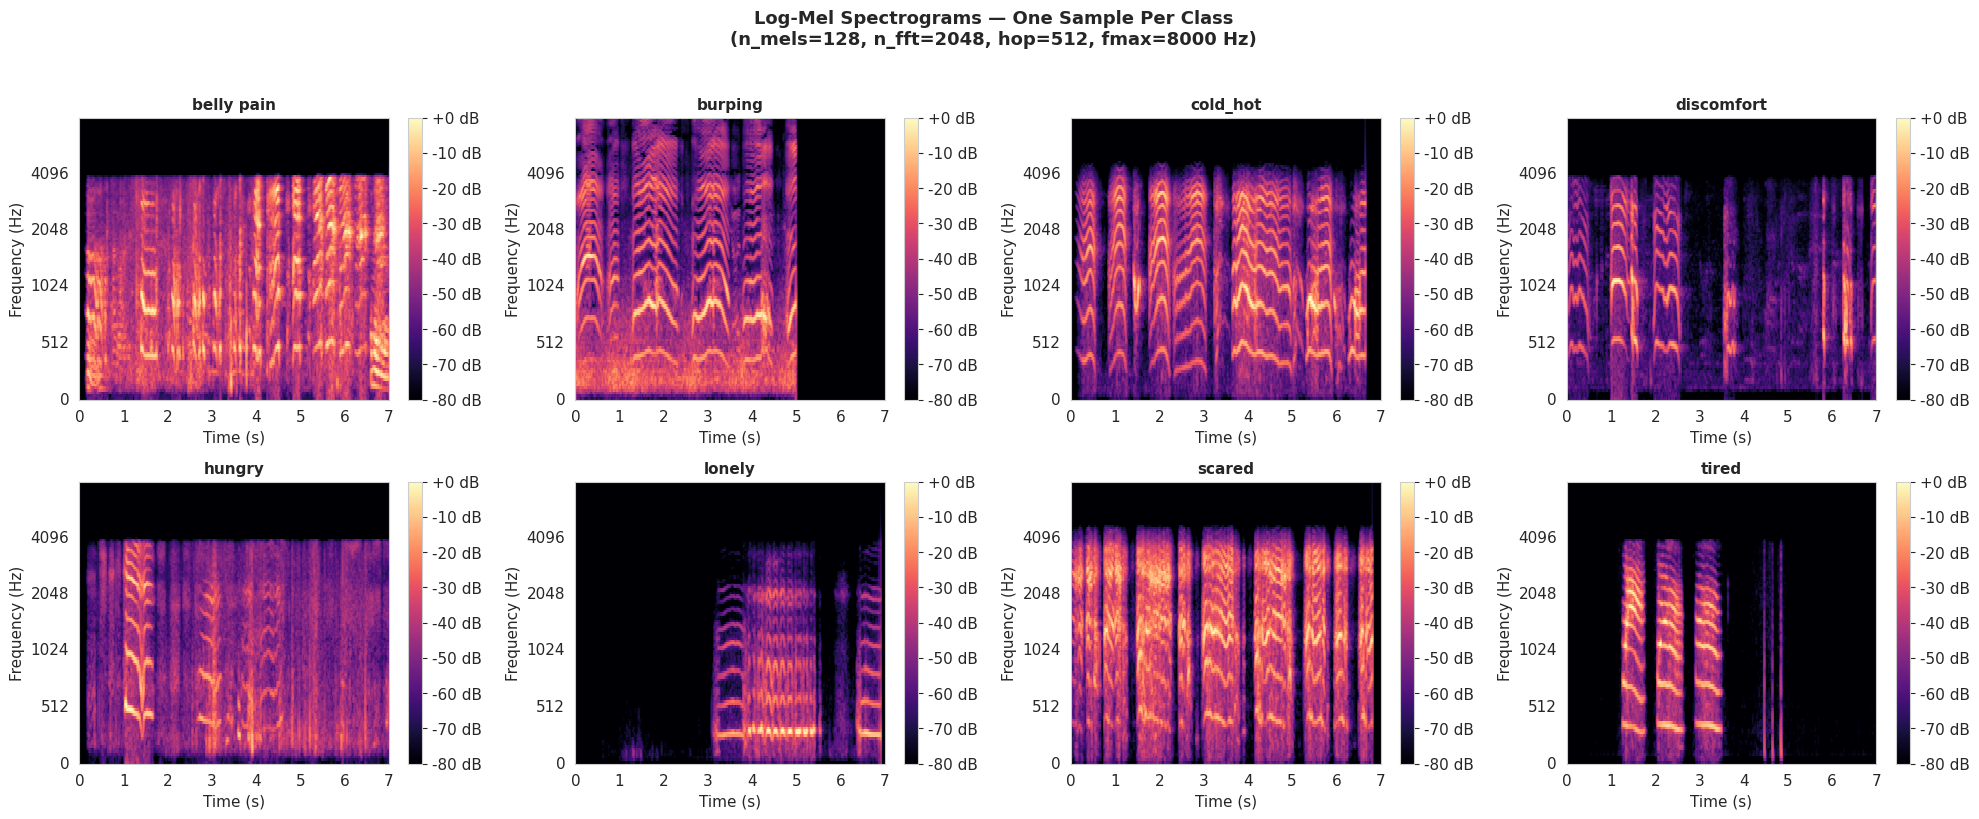

Saved: spectrograms_per_class.png


In [39]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

# Use only original (non-augmented) samples for visualisation
df_orig = df_manifest[~df_manifest['is_augmented']].copy()

for idx, cat in enumerate(CLASSES):
    cat_df   = df_orig[df_orig['category'] == cat]
    # Pick the sample closest to the class-median index (stable representative)
    rep_row  = cat_df.iloc[len(cat_df) // 2]

    audio_path = resolve_audio_path(rep_row, AUDIO_BASE_DIR)
    audio, _   = librosa.load(audio_path, sr=TARGET_SR)

    mel_spec    = librosa.feature.melspectrogram(
        y=audio, sr=TARGET_SR, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=FMAX
    )
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)

    img = librosa.display.specshow(
        log_mel, sr=TARGET_SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', fmax=FMAX,
        ax=axes[idx], cmap='magma'
    )
    axes[idx].set_title(f'{cat}', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Time (s)')
    axes[idx].set_ylabel('Frequency (Hz)')
    plt.colorbar(img, ax=axes[idx], format='%+2.0f dB')

plt.suptitle('Log-Mel Spectrograms — One Sample Per Class\n'
             f'(n_mels={N_MELS}, n_fft={N_FFT}, hop={HOP_LENGTH}, fmax={FMAX} Hz)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'spectrograms_per_class.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: spectrograms_per_class.png")


### 5.2 Waveform vs Log-Mel Spectrogram — hungry vs belly_pain

This is the **breakthrough visualisation** demonstrating why spectrograms
are the correct input representation over raw waveforms.

- The waveform (left) shows amplitude-over-time only. Two very different cry
  types can produce nearly identical amplitude envelopes — the waveform
  cannot distinguish them visually.
- The Log-Mel Spectrogram (right) reveals the frequency structure at each
  time step: harmonic bands, spectral centroid position, formant energy
  distribution. These are the features that distinguish cry types, and they
  are invisible in the waveform.


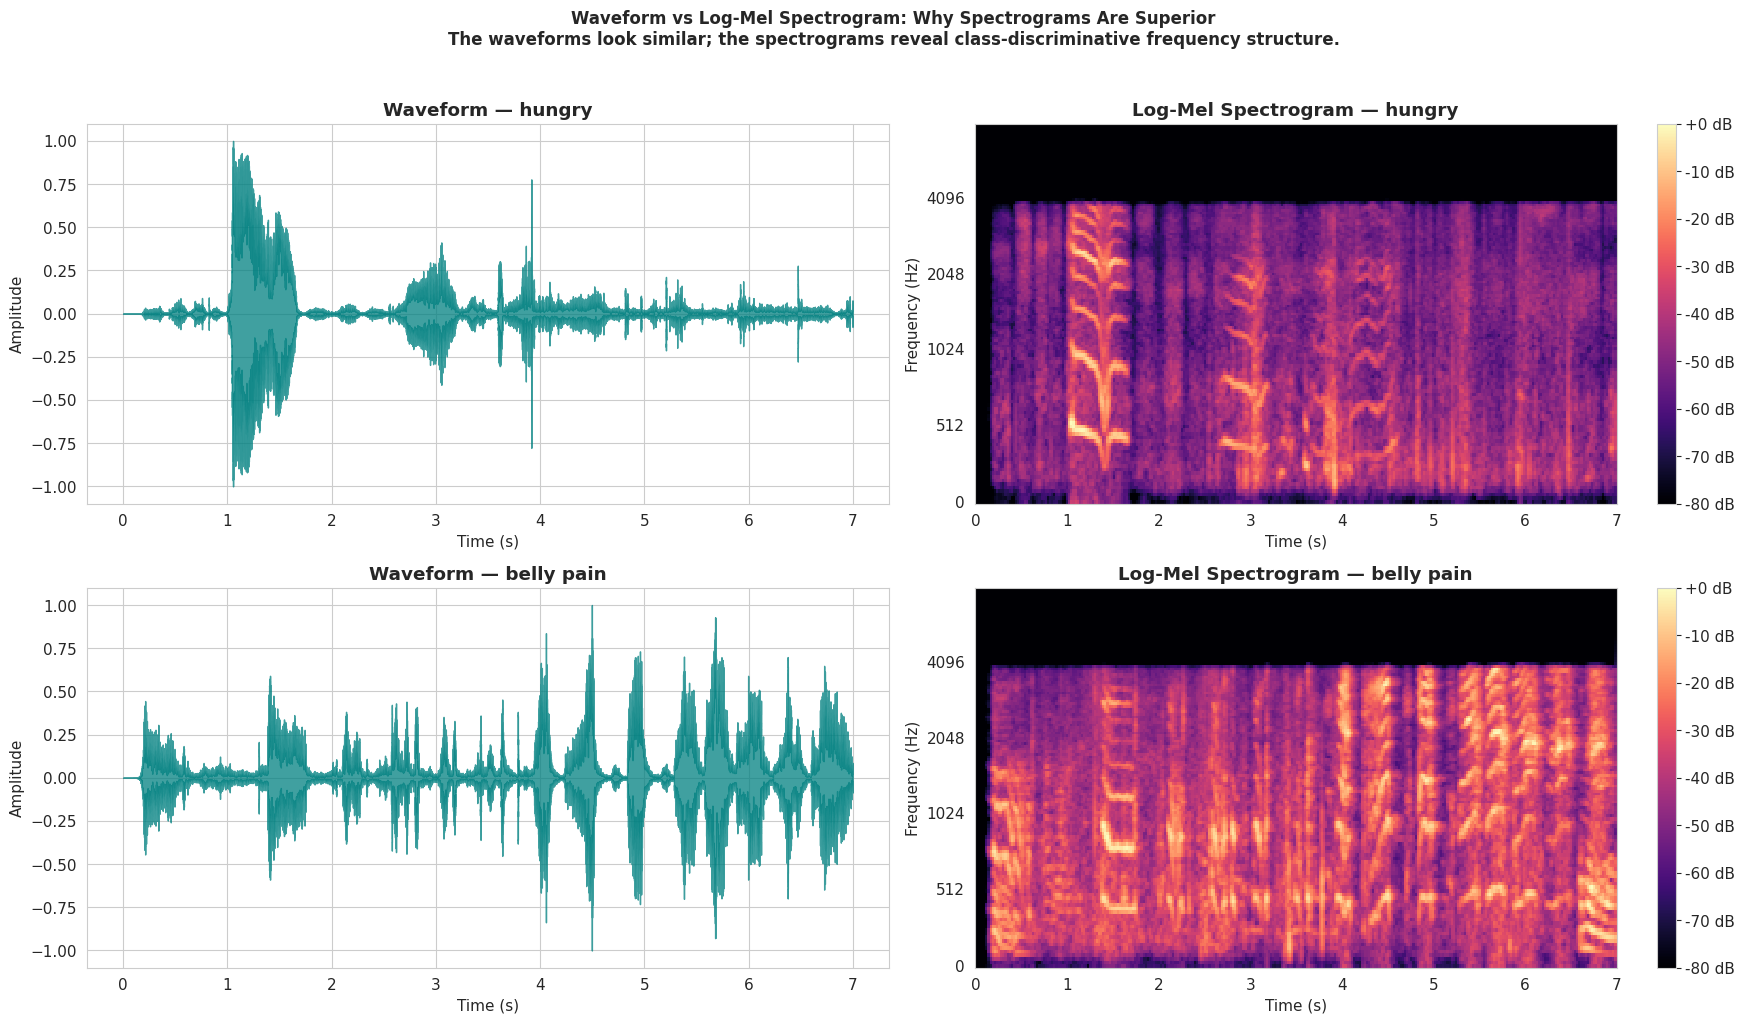

Saved: waveform_vs_spectrogram_hungry_bellypain.png


In [40]:
comparison_cats = ['hungry', 'belly pain']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for row_idx, cat in enumerate(comparison_cats):
    cat_df  = df_orig[df_orig['category'] == cat]
    rep_row = cat_df.iloc[len(cat_df) // 2]

    audio_path = resolve_audio_path(rep_row, AUDIO_BASE_DIR)
    audio, _   = librosa.load(audio_path, sr=TARGET_SR)

    # ── Waveform ─────────────────────────────────────────────────────────────
    librosa.display.waveshow(audio, sr=TARGET_SR,
                              ax=axes[row_idx, 0], color='teal', alpha=0.75)
    axes[row_idx, 0].set_title(f'Waveform — {cat}', fontweight='bold')
    axes[row_idx, 0].set_xlabel('Time (s)')
    axes[row_idx, 0].set_ylabel('Amplitude')
    axes[row_idx, 0].set_ylim(-1.1, 1.1)

    # ── Log-Mel Spectrogram ───────────────────────────────────────────────────
    mel_spec = librosa.feature.melspectrogram(
        y=audio, sr=TARGET_SR, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=FMAX
    )
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)

    img = librosa.display.specshow(
        log_mel, sr=TARGET_SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', fmax=FMAX,
        ax=axes[row_idx, 1], cmap='magma'
    )
    axes[row_idx, 1].set_title(f'Log-Mel Spectrogram — {cat}', fontweight='bold')
    axes[row_idx, 1].set_xlabel('Time (s)')
    axes[row_idx, 1].set_ylabel('Frequency (Hz)')
    plt.colorbar(img, ax=axes[row_idx, 1], format='%+2.0f dB')

plt.suptitle('Waveform vs Log-Mel Spectrogram: Why Spectrograms Are Superior\n'
             'The waveforms look similar; the spectrograms reveal class-discriminative frequency structure.',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'waveform_vs_spectrogram_hungry_bellypain.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: waveform_vs_spectrogram_hungry_bellypain.png")


### 5.3 Confused Pairs Spectrograms — Visualising Why SVM Struggles

EDA identified the three most confused class pairs by nearest-neighbour overlap:

| Pair | Neighbour Overlaps |
|------|--------------------|
| discomfort ↔ hungry | 1074 |
| hungry ↔ tired | 976 |
| cold_hot ↔ hungry | 899 |

The spectrograms below show why these pairs are hard to separate.
Both classes in each pair share similar mid-frequency energy bands
(200–800 Hz range). An SVM operating on 38,656-dimensional flattened
spectrogram vectors cannot learn the subtle local spectro-temporal
patterns that distinguish them — this is precisely the limitation
that the Depthwise Separable CNN (Phase 2) is designed to overcome.


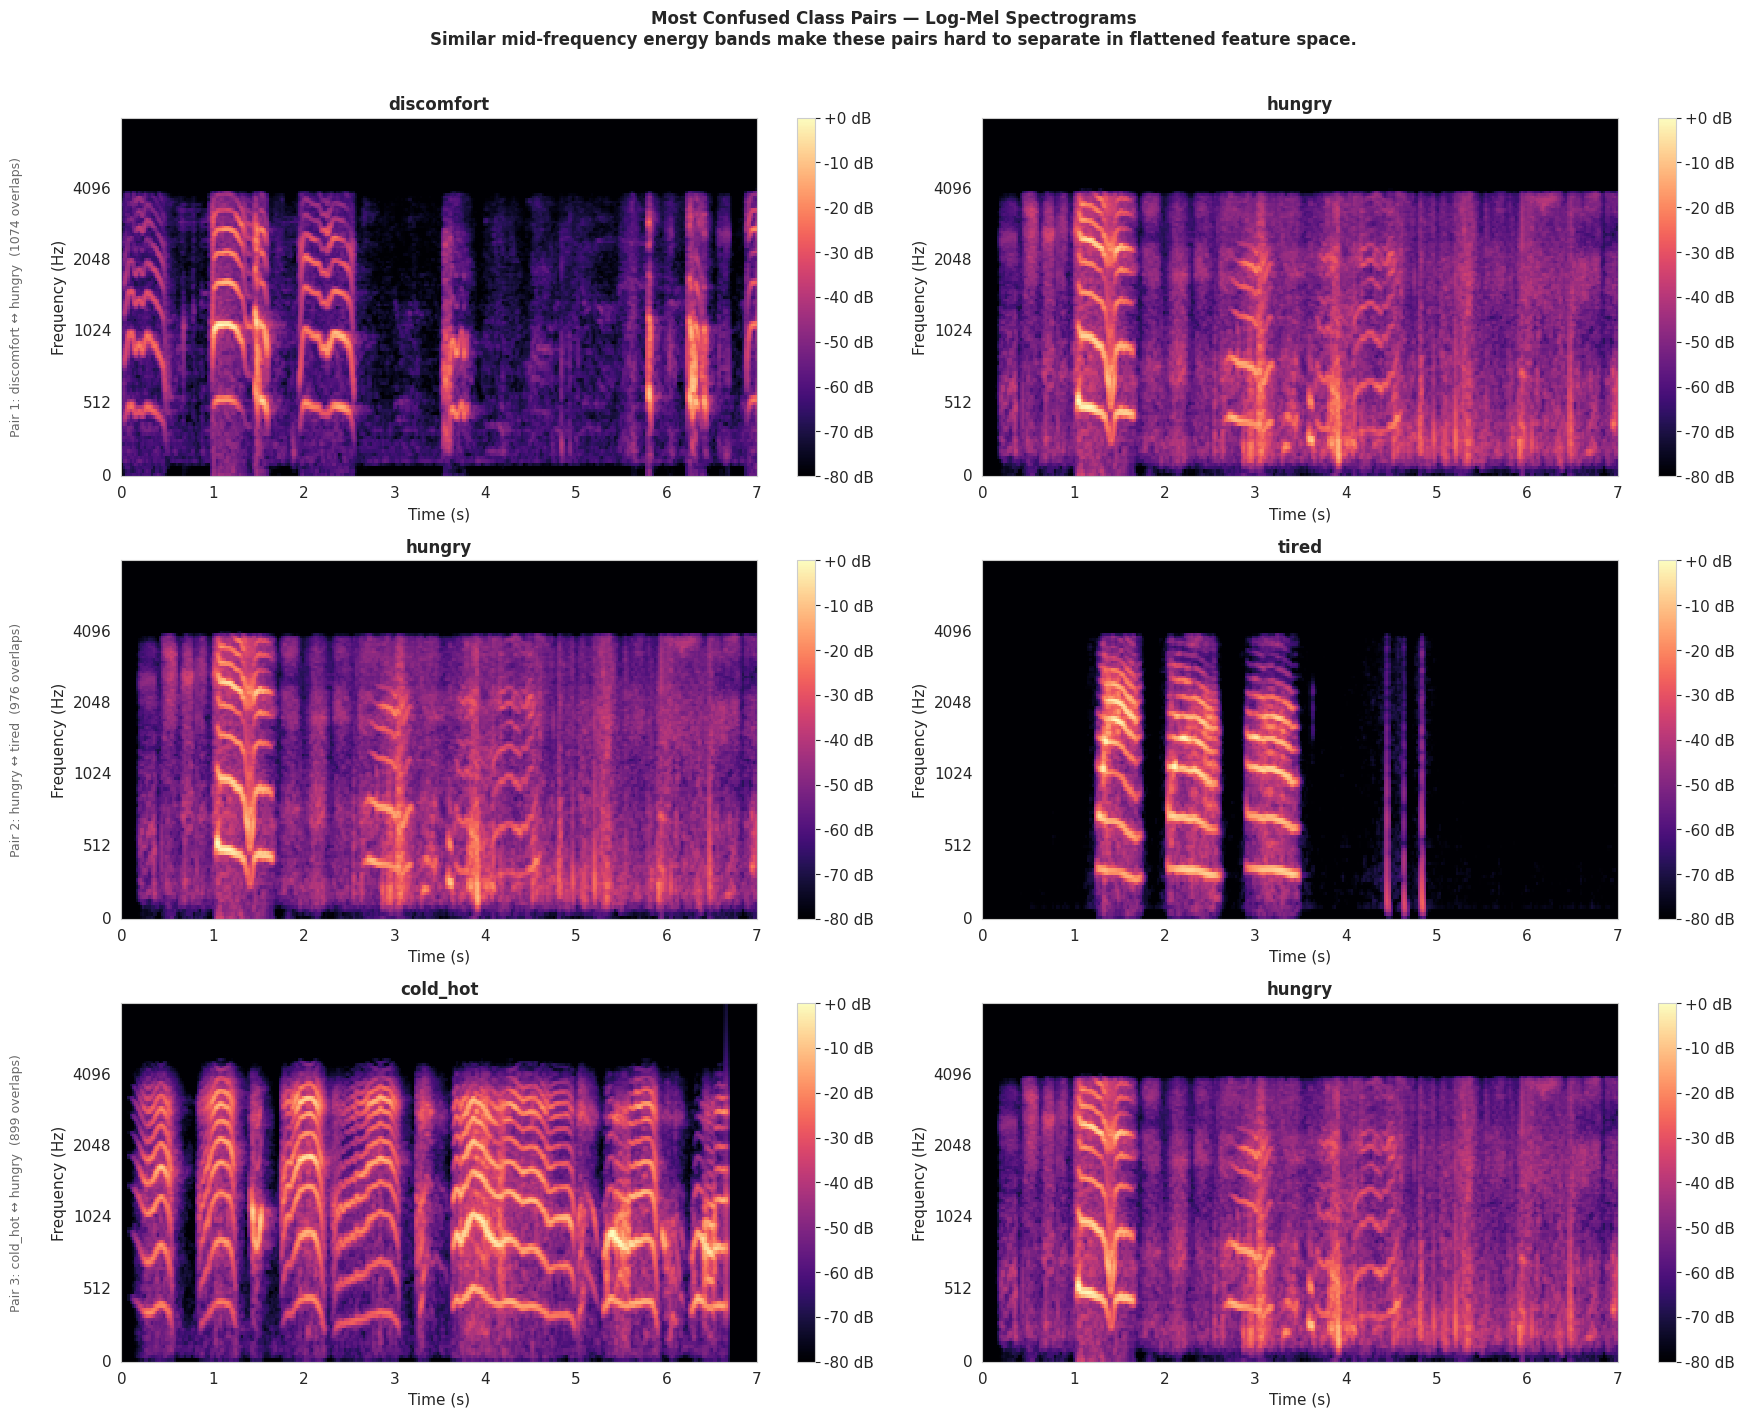

Saved: confused_pairs_spectrograms.png


In [41]:
confused_pairs = [
    ('discomfort', 'hungry',   'discomfort ↔ hungry  (1074 overlaps)'),
    ('hungry',     'tired',    'hungry ↔ tired  (976 overlaps)'),
    ('cold_hot',   'hungry',   'cold_hot ↔ hungry  (899 overlaps)'),
]

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

for row_idx, (cat_a, cat_b, title) in enumerate(confused_pairs):
    for col_idx, cat in enumerate([cat_a, cat_b]):
        cat_df  = df_orig[df_orig['category'] == cat]
        rep_row = cat_df.iloc[len(cat_df) // 2]

        audio_path = resolve_audio_path(rep_row, AUDIO_BASE_DIR)
        audio, _   = librosa.load(audio_path, sr=TARGET_SR)

        mel_spec = librosa.feature.melspectrogram(
            y=audio, sr=TARGET_SR, n_mels=N_MELS,
            n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=FMAX
        )
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)

        img = librosa.display.specshow(
            log_mel, sr=TARGET_SR, hop_length=HOP_LENGTH,
            x_axis='time', y_axis='mel', fmax=FMAX,
            ax=axes[row_idx, col_idx], cmap='magma'
        )
        axes[row_idx, col_idx].set_title(f'{cat}', fontweight='bold', fontsize=12)
        axes[row_idx, col_idx].set_xlabel('Time (s)')
        axes[row_idx, col_idx].set_ylabel('Frequency (Hz)')
        plt.colorbar(img, ax=axes[row_idx, col_idx], format='%+2.0f dB')

    # Annotate pair label on the left
    axes[row_idx, 0].annotate(
        f'Pair {row_idx+1}: {title}',
        xy=(0, 0.5), xycoords='axes fraction',
        xytext=(-80, 0), textcoords='offset points',
        fontsize=9, color='dimgray', rotation=90, va='center'
    )

plt.suptitle('Most Confused Class Pairs — Log-Mel Spectrograms\n'
             'Similar mid-frequency energy bands make these pairs hard to separate in flattened feature space.',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'confused_pairs_spectrograms.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confused_pairs_spectrograms.png")


## Section 6 — Shape Verification and Statistics

Final verification of the generated arrays before saving.


In [42]:
print("FINAL ARRAY VERIFICATION")
print("=" * 60)
print(f"  X.shape         : {X.shape}")
print(f"  y.shape         : {y.shape}")
print(f"  Expected X shape: ({len(df_manifest) - len(failed_files)}, {N_MELS}, {T_FRAMES})")
print()
print(f"  X dtype         : {X.dtype}")
print(f"  y dtype         : {y.dtype}")
print()
print(f"  X global min    : {X.min():.4f} dB")
print(f"  X global max    : {X.max():.4f} dB")
print(f"  X global mean   : {X.mean():.4f} dB")
print(f"  X global std    : {X.std():.4f} dB")
print()
print(f"  NaN in X        : {np.isnan(X).sum()}")
print(f"  Inf in X        : {np.isinf(X).sum()}")
print()

# Per-class sample count in y
print("CLASS DISTRIBUTION IN y (encoded labels)")
print("-" * 50)
for cls, enc in LABEL_ENCODER.items():
    count = int((y == enc).sum())
    print(f"  [{enc}] {cls:>15s} : {count} samples")

# Hard assertion
assert X.shape[1] == N_MELS,    f"Mel bins mismatch: {X.shape[1]} vs {N_MELS}"
assert X.shape[2] == T_FRAMES,  f"Time frames mismatch: {X.shape[2]} vs {T_FRAMES}"
assert np.isnan(X).sum() == 0,  "NaN values found in X"
assert np.isinf(X).sum() == 0,  "Inf values found in X"
print("\nAll assertions PASSED. Arrays are ready to save.")


FINAL ARRAY VERIFICATION
  X.shape         : (1334, 128, 302)
  y.shape         : (1334,)
  Expected X shape: (1334, 128, 302)

  X dtype         : float32
  y dtype         : int32

  X global min    : -80.0000 dB
  X global max    : 0.0000 dB
  X global mean   : -58.0316 dB
  X global std    : 18.4463 dB

  NaN in X        : 0
  Inf in X        : 0

CLASS DISTRIBUTION IN y (encoded labels)
--------------------------------------------------
  [0]      belly pain : 133 samples
  [1]         burping : 130 samples
  [2]        cold_hot : 130 samples
  [3]      discomfort : 142 samples
  [4]          hungry : 397 samples
  [5]          lonely : 130 samples
  [6]          scared : 130 samples
  [7]           tired : 142 samples

All assertions PASSED. Arrays are ready to save.


## Section 7 — Save Arrays and Label Encoder

Save the three artefacts consumed by `04_baseline_ml.ipynb`:

| File | Description |
|------|-------------|
| `data/processed/X.npy` | Float32 spectrogram array, shape (N, 128, 302) |
| `data/processed/y.npy` | Int32 label array, shape (N,) |
| `data/processed/label_encoder.json` | Dict mapping class name → integer index |

Note: `X.npy` and `y.npy` are gitignored (too large for version control).
`label_encoder.json` is committed to the repository.


In [43]:
X_PATH     = os.path.join(OUTPUT_DIR, 'X.npy')
Y_PATH     = os.path.join(OUTPUT_DIR, 'y.npy')
LABEL_PATH = os.path.join(OUTPUT_DIR, 'label_encoder.json')

np.save(X_PATH, X)
np.save(Y_PATH, y)

with open(LABEL_PATH, 'w') as f:
    json.dump({'encoder': LABEL_ENCODER, 'decoder': LABEL_DECODER}, f, indent=2)

print("SAVED")
print("=" * 50)
print(f"  X.npy              : {os.path.getsize(X_PATH) / 1e6:.1f} MB   {X.shape}")
print(f"  y.npy              : {os.path.getsize(Y_PATH) / 1e3:.1f} KB   {y.shape}")
print(f"  label_encoder.json : {os.path.getsize(LABEL_PATH)} bytes")


SAVED
  X.npy              : 206.3 MB   (1334, 128, 302)
  y.npy              : 5.5 KB   (1334,)
  label_encoder.json : 348 bytes


## Section 8 — Reload Verification

Reload the saved arrays from disk and verify shapes and class distribution
to confirm no data was corrupted during saving.


In [44]:
X_check = np.load(X_PATH)
y_check = np.load(Y_PATH)

with open(LABEL_PATH, 'r') as f:
    label_data = json.load(f)

print("RELOAD VERIFICATION")
print("=" * 60)
print(f"  X_check.shape : {X_check.shape}")
print(f"  y_check.shape : {y_check.shape}")
print(f"  X match       : {np.allclose(X, X_check)}")
print(f"  y match       : {np.array_equal(y, y_check)}")
print()
print("Label encoder loaded:")
for cls, enc in label_data['encoder'].items():
    count = int((y_check == enc).sum())
    print(f"  [{enc}] {cls:>15s} : {count} samples in y")

assert X_check.shape == X.shape,         "Saved X shape does not match in-memory X"
assert np.array_equal(y, y_check),       "Saved y does not match in-memory y"
print("\nReload verification PASSED. Feature engineering complete.")


RELOAD VERIFICATION
  X_check.shape : (1334, 128, 302)
  y_check.shape : (1334,)
  X match       : True
  y match       : True

Label encoder loaded:
  [0]      belly pain : 133 samples in y
  [1]         burping : 130 samples in y
  [2]        cold_hot : 130 samples in y
  [3]      discomfort : 142 samples in y
  [4]          hungry : 397 samples in y
  [5]          lonely : 130 samples in y
  [6]          scared : 130 samples in y
  [7]           tired : 142 samples in y

Reload verification PASSED. Feature engineering complete.


## Section 9 — Summary

### What Was Built

This notebook converted 1334 preprocessed audio files into Log-Mel Spectrograms
and saved them as NumPy arrays ready for model training.

### Key Outputs

| Artefact | Value |
|----------|-------|
| X shape | (1334, 128, 302) |
| y shape | (1334,) |
| Spectrogram dtype | float32 |
| dB range | −80.0000 to 0.0000 dB |
| Failed files | 0 |

### Parameter Decisions (Viva-Ready Justifications)

| Parameter | Value | Justification |
|-----------|-------|---------------|
| `n_mels=128` | 128 | Matches human critical-band resolution; standard for audio CNN literature |
| `n_fft=2048` | 2048 | 93 ms window — captures 400 Hz fundamental with temporal resolution |
| `hop_length=512` | 512 | 23 ms stride, 75% overlap — standard trade-off |
| `fmax=8000` | 8000 Hz | Covers full infant cry harmonic range; discards noise above 8 kHz |
| `ref=np.max` | peak | Normalises each clip's energy to [−80, 0] dB for consistent CNN input |

### Next Step

Run `04_baseline_ml.ipynb` to:
- Load `X.npy` and `y.npy`
- Flatten spectrograms to (1334, 38656) for SVM input
- Train Model A (SVM baseline) and produce the Ablation Table stub
